# Maliar-Maliar-Winant Deep Learning Method: RBC Warm-up in Julia

This notebook uses the Euler-equation deep learning method in Maliar, Maliar, and Winant (2021) to solve a small stochastic RBC model. A neural network approximates the consumption policy, and its parameters are trained by minimizing simulated Euler-equation residuals with `Flux.gradient` and Adam. We use the log-utility, full-depreciation Brock-Mirman case so the learned policy can be compared with the analytical policy function.

## 1) RBC Model

A representative household chooses consumption and next-period capital:

$$
\max_{\{c_t,k_{t+1}\}} E_0 \sum_{t=0}^{\infty}\beta^t \frac{c_t^{1-\gamma}-1}{1-\gamma}
$$

subject to

$$
c_t+k_{t+1}=e^{z_t}k_t^\alpha+(1-\delta)k_t,
$$

$$
z_{t+1}=\rho_z z_t+\sigma_z\epsilon_{t+1}, \qquad \epsilon_{t+1}\sim N(0,1).
$$

For the analytic benchmark in this notebook, we use the Brock-Mirman special case with log utility and full depreciation:

$$
\gamma=1, \qquad \delta=1, \qquad u(c)=\log c.
$$

The Euler equation is

$$
1
=
\beta E_t\left[\left(\frac{c_{t+1}}{c_t}\right)^{-\gamma}
\left(\alpha e^{z_{t+1}}k_{t+1}^{\alpha-1}+1-\delta\right)\right].
$$

Maliar et al. turn this condition into a loss:

$$
\mathcal L(\theta)=E\left[ R(k,z,\epsilon;\theta)^2\right],
$$

where $R$ is the Euler residual implied by a neural-network policy rule. In the Brock-Mirman special case, the exact policy rule is available in closed form, so we can directly compare the neural-network policy with the analytical benchmark.

## 2) Julia Setup

The notebook activates the local Julia project and uses `Flux.gradient` for automatic differentiation of the Euler-equation loss.

In [1]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        if isfile(joinpath(dir, "Project.toml"))
            return dir
        end
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using Random
using LinearAlgebra
using Statistics
using Printf
using Flux
using Plots

include("src/NetworkDiagram.jl")

  Activating project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\DeepLearningMacro`


plot_policy_network_diagram

## 3) Calibration and Steady State

The deterministic steady state satisfies

$$
\frac{1}{\beta}=\alpha K^{\alpha-1}+1-\delta.
$$

In [ ]:
Base.@kwdef struct RBCParams
    beta::Float64 = 0.96
    gamma::Float64 = 1.0
    alpha::Float64 = 0.36
    delta::Float64 = 1.0
    rho_z::Float64 = 0.90
    sigma_z::Float64 = 0.01

    hidden::Int = 8 # number of hidden units in the neural network
    xi_min::Float64 = 0.02
    xi_max::Float64 = 0.98
end

function steady_state(p::RBCParams)
    K = ((1 / p.beta - (1 - p.delta)) / p.alpha)^(1 / (p.alpha - 1))
    Y = K^p.alpha
    C = Y - p.delta * K
    W = Y + (1 - p.delta) * K
    xi = C / W
    return (; K, Y, C, W, xi)
end

function analytic_policy_ck(k, z, p::RBCParams)
    if !(isapprox(p.gamma, 1.0) && isapprox(p.delta, 1.0))
        error("The closed-form policy below is only valid for gamma = 1 and delta = 1.")
    end
    y = exp(z) * k^p.alpha
    c = (1 - p.alpha * p.beta) * y
    kp = p.alpha * p.beta * y
    return c, kp
end

par = RBCParams()
ss = steady_state(par)

@printf("K_ss = %.4f\n", ss.K)
@printf("C_ss = %.4f\n", ss.C)
@printf("steady-state consumption/resource share xi_ss = %.4f\n", ss.xi)

K_ss = 0.1901
C_ss = 0.3600
steady-state consumption/resource share xi_ss = 0.6544


## 4) Neural-Network Policy Rule

We parameterize the policy by a consumption share:

$$
\xi(k,z;\theta)\in(\xi_{\min},\xi_{\max})=(0.02,0.98).
$$

Given resources

$$
w(k,z)=e^zk^\alpha+(1-\delta)k,
$$

the implied policy is

$$
c(k,z;\theta)=\xi(k,z;\theta)w(k,z),\qquad
k'(k,z;\theta)=\left[1-\xi(k,z;\theta)\right]w(k,z).
$$

Hence feasibility holds by construction:

$$
c>0,\qquad k'>0,\qquad c+k'=w(k,z).
$$

The neural-network input is the normalized state

$$
x(k,z)=\begin{bmatrix}
\left(\log k-\log K_{ss}\right)/0.25\\
z/\max\left(2\sigma_z/\sqrt{1-\rho_z^2},10^{-8}\right)
\end{bmatrix}.
$$

With one hidden layer of $H=8$ neurons,

$$
s_1=W_1x+b_1,\qquad h=\tanh(s_1),\qquad h\in(-1,1)^8,
$$

where the hidden-layer activation is

$$
\tanh(s)=\frac{e^s-e^{-s}}{e^s+e^{-s}}=\frac{e^{2s}-1}{e^{2s}+1}.
$$

The output layer maps $h$ into one scalar share:

$$
a=W_2h+b_2,\qquad \sigma(a)=\frac{1}{1+e^{-a}},
$$

$$
\xi(k,z;\theta)=\xi_{\min}+(\xi_{\max}-\xi_{\min})\sigma(a(k,z;\theta)).
$$

Thus the network input is $x\in\mathbb R^2$, the network output is the scalar $\xi\in(0.02,0.98)$, and the economic objects are $c$ and $k'$. The bounds avoid the unstable endpoints $c\approx 0$ and $k'\approx 0$.

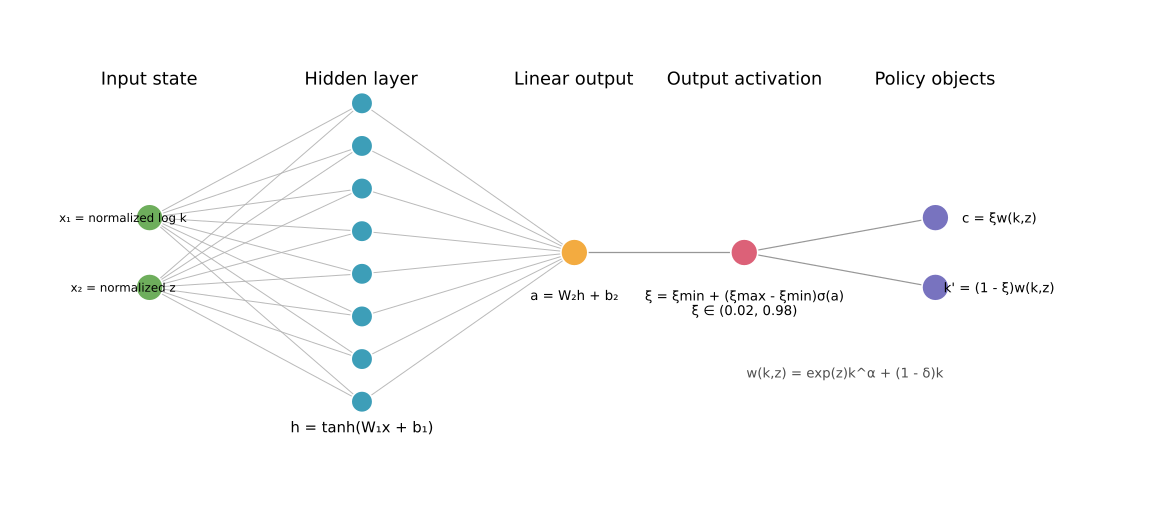

In [3]:
plot_policy_network_diagram(hidden=par.hidden, xi_min=par.xi_min, xi_max=par.xi_max)

In [4]:
function sigmoid_stable(x)
    if x >= 0
        q = exp(-x)
        return 1 / (1 + q)
    else
        q = exp(x)
        return q / (1 + q)
    end
end

logit(x) = log(x / (1 - x))

function nparams(p::RBCParams)
    H = p.hidden
    return 2 * H + H + H + 1       # W1, b1, W2, b2
end

function unpack(theta, p::RBCParams)
    H = p.hidden
    i = 1
    W1 = reshape(theta[i:(i + 2H - 1)], H, 2)
    i += 2H
    b1 = theta[i:(i + H - 1)]
    i += H
    W2 = theta[i:(i + H - 1)]
    i += H
    b2 = theta[i]
    return W1, b1, W2, b2
end

function init_theta(rng::AbstractRNG, p::RBCParams, ss)
    theta = 0.05 .* randn(rng, nparams(p))
    q = (ss.xi - p.xi_min) / (p.xi_max - p.xi_min)
    theta[end] = logit(q)
    return theta
end

function normalize_state(k, z, p::RBCParams, ss)
    zsd = p.sigma_z / sqrt(1 - p.rho_z^2)
    return [(log(k) - log(ss.K)) / 0.25, z / max(2zsd, 1e-8)]
end

function policy_share(theta, k, z, p::RBCParams, ss)
    W1, b1, W2, b2 = unpack(theta, p)
    x = normalize_state(k, z, p, ss)
    h = tanh.(W1 * x .+ b1)
    raw = dot(W2, h) + b2
    return p.xi_min + (p.xi_max - p.xi_min) * sigmoid_stable(raw)
end

resources(k, z, p::RBCParams) = exp(z) * k^p.alpha + (1 - p.delta) * k
gross_return(k, z, p::RBCParams) = p.alpha * exp(z) * k^(p.alpha - 1) + 1 - p.delta

function policy_ck(theta, k, z, p::RBCParams, ss)
    xi = policy_share(theta, k, z, p, ss)
    w = resources(k, z, p)
    c = max(xi * w, 1e-10)
    kp = max(w - c, 1e-10)
    return c, kp, xi
end

rng = MersenneTwister(1234)
theta = init_theta(rng, par, ss)

c0, kp0, xi0 = policy_ck(theta, ss.K, 0.0, par, ss)
@printf("Initial NN at steady state: c = %.4f, k' = %.4f, xi = %.4f\n", c0, kp0, xi0)

Initial NN at steady state: c = 0.3595, k' = 0.1906, xi = 0.6534


## 5) Euler Residual as the Loss

For one simulated point $(k,z,\epsilon')$, define

$$
z'=\rho_z z+\sigma_z\epsilon',
$$

$$
R(k,z,\epsilon';\theta)
=
\beta
\frac{u'(c(k',z';\theta))}{u'(c(k,z;\theta))}
\left(\alpha e^{z'}(k')^{\alpha-1}+1-\delta\right)
-1.
$$

The training loss averages $R^2$ over a batch. Using one draw of $\epsilon'$ per state is the small-model analogue of the all-in-one Monte Carlo operator in the paper.

In [5]:
uprime(c, p::RBCParams) = c^(-p.gamma)

function euler_residual(theta, k, z, eps_next, p::RBCParams, ss)
    c, kp, _ = policy_ck(theta, k, z, p, ss)
    zp = p.rho_z * z + p.sigma_z * eps_next
    cp, _, _ = policy_ck(theta, kp, zp, p, ss)
    retp = gross_return(kp, zp, p)
    return p.beta * uprime(cp, p) * retp / uprime(c, p) - 1
end

function euler_loss(theta, k_batch, z_batch, eps_batch, p::RBCParams, ss)
    s = 0.0
    for i in eachindex(k_batch)
        r = euler_residual(theta, k_batch[i], z_batch[i], eps_batch[i], p, ss)
        s += r^2
    end
    return s / length(k_batch)
end

test_k = fill(ss.K, 10)
test_z = zeros(10)
test_eps = randn(rng, 10)
@printf("Initial Euler loss near steady state = %.6e\n", euler_loss(theta, test_k, test_z, test_eps, par, ss))

Initial Euler loss near steady state = 7.606854e-06


## 6) Stochastic Training

Training converts the RBC equilibrium conditions into a loss-minimization problem. The unknown object is the neural-network parameter vector $\theta$, and the target is to make the Euler residual close to zero on simulated state-shock draws.

At each training step, the code does the following:

1. Draw a mini-batch of current states $(k_b,z_b)_{b=1}^B$. Capital is sampled over a broad interval around the steady state, and productivity is sampled from its stationary shock scale. This gives the network training points over the same region where we later plot the policy function.

2. For each state, draw one next-period innovation $\epsilon'_b$. This gives the next productivity state

$$
z'_b=\rho_z z_b+\sigma_z\epsilon'_b.
$$

3. Feed the current state $(k_b,z_b)$ into the neural network. The network outputs a consumption share $\xi(k_b,z_b;\theta)$, which is transformed into current consumption and next-period capital:

$$
c_b=\xi(k_b,z_b;\theta)e^{z_b}k_b^\alpha,
\qquad
k'_b=\left[1-\xi(k_b,z_b;\theta)\right]e^{z_b}k_b^\alpha.
$$

4. Feed the simulated next state $(k'_b,z'_b)$ back into the same neural network to compute next-period consumption $c'_b=c(k'_b,z'_b;\theta)$. This is the dynamic part of the loss: the same policy rule must be consistent today and tomorrow.

5. Compute the Euler residual for every draw in the mini-batch:

$$
R_b(\theta)
=
\beta
\frac{u'(c'_b)}{u'(c_b)}
\left(\alpha e^{z'_b}(k'_b)^{\alpha-1}\right)
-1.
$$

The batch loss is the average squared residual:

$$
\mathcal L(\theta)
=
\frac{1}{B}\sum_{b=1}^{B} R_b(\theta)^2.
$$

6. Use `Flux.gradient` to compute $\nabla_\theta\mathcal L(\theta)$ and update $\theta$ with Adam. Adam is a stochastic-gradient optimizer that keeps two running statistics of the gradient: a momentum term $m_t$ and a squared-gradient scale term $v_t$:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,
\qquad
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2,
$$

where $g_t=\nabla_\theta\mathcal L(\theta_t)$. After bias correction, the parameter update is approximately

$$
\theta_{t+1}
=
\theta_t
-
\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}.
$$

Intuitively, $m_t$ smooths noisy mini-batch gradients, while $v_t$ rescales each parameter's step size so parameters with volatile gradients move more cautiously. Repeating this stochastic procedure trains the policy network to satisfy the Euler equation over the simulated state space, rather than only at the deterministic steady state.

In [6]:
mutable struct AdamState
    m::Vector{Float64}
    v::Vector{Float64}
    t::Int
end

function AdamState(n::Int)
    return AdamState(zeros(n), zeros(n), 0)
end

function adam_step!(theta, grad, st::AdamState; lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8)
    st.t += 1
    st.m .= beta1 .* st.m .+ (1 - beta1) .* grad
    st.v .= beta2 .* st.v .+ (1 - beta2) .* (grad .^ 2)
    mhat = st.m ./ (1 - beta1^st.t)
    vhat = st.v ./ (1 - beta2^st.t)
    theta .-= lr .* mhat ./ (sqrt.(vhat) .+ eps)
    return theta
end

function ad_gradient(theta, lossfun)
    grad = Flux.gradient(lossfun, theta)[1]
    return grad
end

function sample_states(rng::AbstractRNG, n::Int, p::RBCParams, ss)
    zsd = p.sigma_z / sqrt(1 - p.rho_z^2)
    log_k_min = log(0.55 * ss.K)
    log_k_max = log(1.60 * ss.K)
    k = exp.(log_k_min .+ (log_k_max - log_k_min) .* rand(rng, n))
    z = clamp.(zsd .* randn(rng, n), -3zsd, 3zsd)
    return k, z
end

function train!(theta, p::RBCParams, ss; steps=500, batch_size=256, lr=0.01, seed=2026, display_step=100)
    rng = MersenneTwister(seed)
    k_batch, z_batch = sample_states(rng, batch_size, p, ss)
    opt = AdamState(length(theta))
    loss_history = Float64[]

    for it in 1:steps
        k_batch, z_batch = sample_states(rng, batch_size, p, ss)
        eps_batch = randn(rng, batch_size)
        lossfun = th -> euler_loss(th, k_batch, z_batch, eps_batch, p, ss)
        grad = ad_gradient(theta, lossfun)
        adam_step!(theta, grad, opt; lr=lr)
        push!(loss_history, lossfun(theta))

        if it == 1 || it % display_step == 0
            @printf("step %5d | loss %.6e | mean(k) %.4f | mean(z) %.4f\n", it, loss_history[end], mean(k_batch), mean(z_batch))
        end
    end

    return (; theta, loss_history, k_batch, z_batch)
end

train! (generic function with 1 method)

Run the training cell below. If it is too slow, reduce `steps` to 300. If the loss is very noisy, increase `batch_size` or reduce `lr`.

In [7]:
theta = init_theta(MersenneTwister(1234), par, ss)
result = train!(theta, par, ss; steps=500, batch_size=256, lr=0.01, display_step=100);

step     1 | loss 8.261010e-05 | mean(k) 0.1893 | mean(z) -0.0025
step   100 | loss 1.237905e-09 | mean(k) 0.1882 | mean(z) -0.0000
step   200 | loss 5.982725e-13 | mean(k) 0.1882 | mean(z) -0.0008
step   300 | loss 2.869073e-13 | mean(k) 0.1893 | mean(z) 0.0003
step   400 | loss 2.990494e-13 | mean(k) 0.1837 | mean(z) 0.0000
step   500 | loss 6.657165e-13 | mean(k) 0.1908 | mean(z) 0.0026


## 7) Diagnostics

First inspect the training loss. Then evaluate Euler residuals out of sample. In a full implementation, we would report log10 Euler errors as in the computational economics literature.

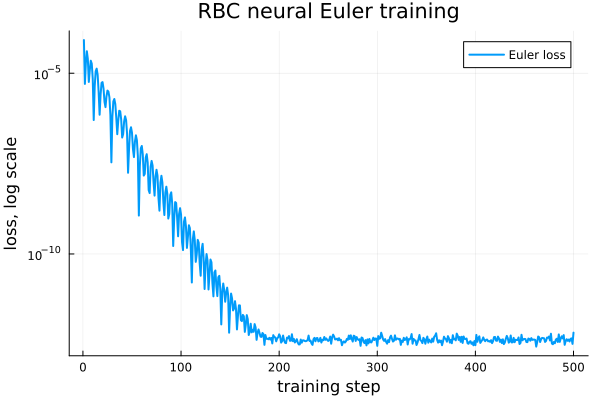

In [8]:
plot(result.loss_history, yscale=:log10, lw=2, label="Euler loss")
xlabel!("training step")
ylabel!("loss, log scale")
title!("RBC neural Euler training")

mean log10 Euler error = -6.4996
median log10 Euler error = -6.4294
p90 log10 Euler error = -6.0510


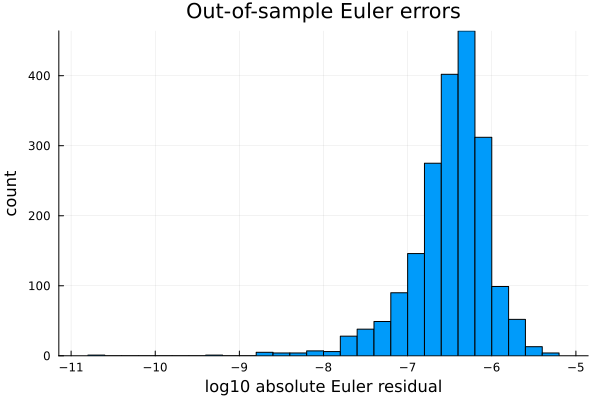

In [9]:
function evaluate_residuals(theta, p::RBCParams, ss; n=2000, seed=99)
    rng = MersenneTwister(seed)
    k, z = sample_states(rng, n, p, ss)
    eps = randn(rng, n)
    r = [euler_residual(theta, k[i], z[i], eps[i], p, ss) for i in 1:n]
    return r, k, z
end

resid, k_eval, z_eval = evaluate_residuals(result.theta, par, ss)
logerr = log10.(abs.(resid) .+ 1e-12)

@printf("mean log10 Euler error = %.4f\n", mean(logerr))
@printf("median log10 Euler error = %.4f\n", median(logerr))
@printf("p90 log10 Euler error = %.4f\n", quantile(logerr, 0.90))

histogram(logerr, bins=40, label=false)
xlabel!("log10 absolute Euler residual")
ylabel!("count")
title!("Out-of-sample Euler errors")

## 7.3) Policy Function: Neural Network vs. Analytical Solution

With log utility and full depreciation, the model has the Brock-Mirman closed-form policy. Guess that the agent saves a constant fraction $s$ of output:

$$
k_{t+1}=s e^{z_t} k_t^\alpha,
\qquad
c_t=(1-s)e^{z_t} k_t^\alpha.
$$

The Euler equation is

$$
1
=
\beta E_t\left[\frac{c_t}{c_{t+1}}\alpha e^{z_{t+1}} k_{t+1}^{\alpha-1}\right].
$$

Under the constant-saving-share guess,

$$
c_{t+1}=(1-s)e^{z_{t+1}}k_{t+1}^\alpha,
$$

so the future shock and $k_{t+1}$ terms cancel inside the Euler equation:

$$
1=\frac{\beta\alpha}{s}.
$$

Therefore,

$$
s=\alpha\beta,
$$

and the exact policy functions are

$$
k'^{\ast}(k,z)=\alpha\beta e^z k^\alpha,
\qquad
c^{\ast}(k,z)=(1-\alpha\beta)e^z k^\alpha.
$$

At $z=0$, these become

$$
k'^{\ast}(k,0)=\alpha\beta k^\alpha,
\qquad
c^{\ast}(k,0)=(1-\alpha\beta)k^\alpha.
$$

The figure below compares this analytical policy with the neural-network policy learned from Euler-residual minimization.

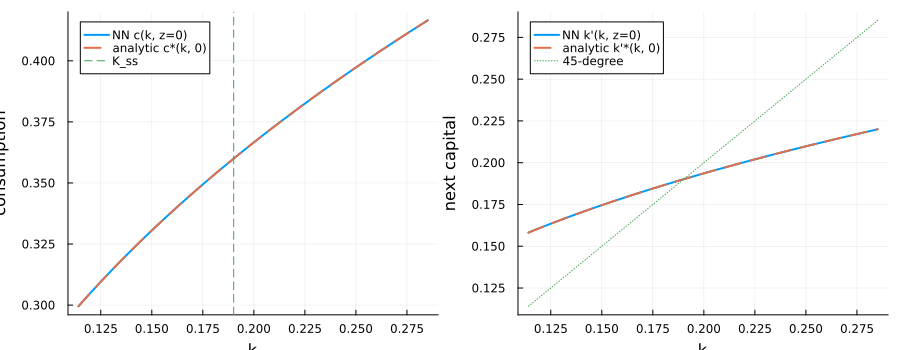

In [10]:
kgrid = collect(range(0.60 * ss.K, 1.50 * ss.K, length=120))
c_policy = [policy_ck(result.theta, k, 0.0, par, ss)[1] for k in kgrid]
kp_policy = [policy_ck(result.theta, k, 0.0, par, ss)[2] for k in kgrid]
c_exact = [analytic_policy_ck(k, 0.0, par)[1] for k in kgrid]
kp_exact = [analytic_policy_ck(k, 0.0, par)[2] for k in kgrid]

p1 = plot(kgrid, c_policy, lw=2, label="NN c(k, z=0)", xlabel="k", ylabel="consumption")
plot!(p1, kgrid, c_exact, lw=2, ls=:dash, label="analytic c*(k, 0)")
vline!(p1, [ss.K], label="K_ss", ls=:dash)
p2 = plot(kgrid, kp_policy, lw=2, label="NN k'(k, z=0)", xlabel="k", ylabel="next capital")
plot!(p2, kgrid, kp_exact, lw=2, ls=:dash, label="analytic k'*(k, 0)")
plot!(p2, kgrid, kgrid, label="45-degree", ls=:dot)
plot(p1, p2, layout=(1, 2), size=(900, 350))